<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%205/week5_text_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5: Text Embedding & Keyword Extraction — QPon Reviews

| | |
|---|---|
| **Input** | `df_qpon_rev.csv` |
| **Author** | Zeldano Shan Oeffie (5026231118) |

Keyword extraction (TF-IDF, RAKE, TextRank), N-gram analysis, and text embeddings applied to QPon app review data.

In [1]:
!pip install rake-nltk sumy sentence-transformers Sastrawi -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 44.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('indonesian'))

---
## 1. Load & Preview Data

In [3]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df):,} rows')
df.head()

Saving df_qpon_rev.csv to df_qpon_rev.csv
Loaded: 4,684 rows


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN,2.21.0.1
3,113779d5-cae5-49f7-b67d-1a885af6f1fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN,2.24.0.1


---
## 2. Preprocessing

In [4]:
df = df.dropna(subset=['content']).reset_index(drop=True)

text = df['content'].iloc[0]
text_clean = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
tokens = word_tokenize(text_clean)
filtered = [w for w in tokens if w not in stop_words and len(w) > 2]

print('Original:', text[:200])
print('\nTokens:', filtered[:20])

Original: tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak sekali di review ini maupun di web yang protes terka

Tokens: ['login', 'alasan', 'aktivitas', 'mencurigakan', 'template', 'solusi', 'sayang', 'disayangkan', 'review', 'web', 'protes', 'terkait', 'login', 'solusi', 'perbaikan', 'apps', 'krusial', 'kek', 'mbanking', 'ewallet']


---
## 3. Keyword Extraction with TF-IDF

In [5]:
documents = df['content'].astype(str).tolist()

vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.todense(), columns=feature_names)

print('Top TF-IDF features across all QPon reviews:')
top_tfidf = tfidf_df.sum().sort_values(ascending=False).head(20)
print(top_tfidf)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


Top TF-IDF features across all QPon reviews:
aplikasi    574.723814
qpon        484.129062
nya         438.857977
ga          344.984384
voucher     324.358585
gak         297.576975
banget      297.364346
promo       282.686723
yg          272.469161
beli        254.489542
refund      249.111023
akun        248.721987
bagus       242.410836
diskon      228.949112
udah        212.758393
login       184.710867
hemat       175.806219
aja         172.495593
makanan     129.258096
bikin       111.001048
dtype: float64


In [6]:
# per-document keywords
for i in range(3):
    scores = tfidf_df.iloc[i].sort_values(ascending=False)
    top = scores[scores > 0].head(5)
    print(f'\nReview {i+1} keywords: {list(top.index)}')
    print(f'  Text: {df["content"].iloc[i][:150]}')


Review 1 keywords: ['login', 'ga']
  Text: tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak se

Review 2 keywords: ['login', 'yg', 'aplikasi']
  Text: aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login dengan device lain. baca revie

Review 3 keywords: ['gak', 'aja', 'aplikasi']
  Text: kapok deh Awal doang enak . sekarang2 mau order aja susah bgt alasannya produk habis lah, jaringan lah, sedang banyak pembeli lah (gak easy user). kom


---
## 4. N-gram Analysis

In [7]:
texts = df['content'].dropna().tolist()

vec_ng = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words), max_features=15)
X_ng = vec_ng.fit_transform(texts)
ngrams = vec_ng.get_feature_names_out()
counts = X_ng.sum(axis=0).A1

ngram_df = pd.DataFrame({'ngram': ngrams, 'count': counts}).sort_values('count', ascending=False)
print('Top N-grams in QPon reviews:')
ngram_df

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


Top N-grams in QPon reviews:


,ngram,count
3,aplikasi qpon,206
0,anak kos,171
12,promo makanan,163
10,hidup hemat,151
11,makanan harian,127
13,promo makanan harian,116
5,beli voucher,110
6,bikin hidup,100
14,worth it,91
1,anak muda,91


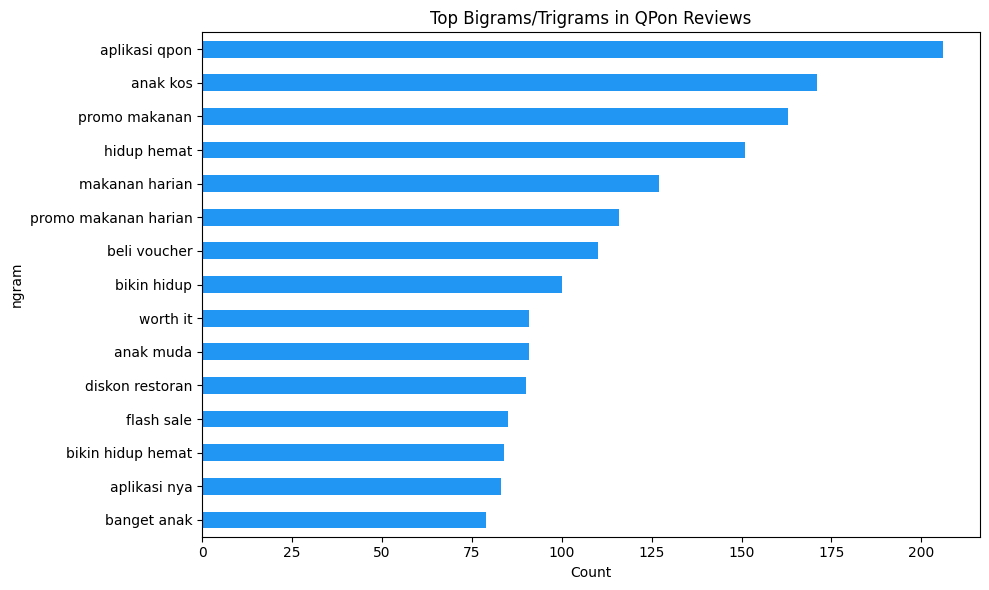

In [8]:
ngram_df.plot.barh(x='ngram', y='count', figsize=(10, 6), color='#2196F3', legend=False)
plt.title('Top Bigrams/Trigrams in QPon Reviews')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Regex Keyword Variations
Searching for keyword variations (like how dosen searched for 'racun', 'basi' etc in MBG data).

In [9]:
# QPon-relevant lemma roots
lemmas = ['error', 'gagal', 'promo', 'cashback', 'voucher']
patterns = {lemma: re.compile(rf'\b\w*{lemma}\w*\b', re.IGNORECASE) for lemma in lemmas}

rows = []
for i, row in df.iterrows():
    text = str(row['content'])
    for lemma, pat in patterns.items():
        matches = pat.findall(text)
        if matches:
            rows.append({'review_idx': i, 'lemma': lemma, 'matches': matches, 'score': row.get('score', None)})

df_lemma = pd.DataFrame(rows)
print(f'Found {len(df_lemma)} matches across {df_lemma["review_idx"].nunique()} reviews')

# summary per lemma
for lemma in lemmas:
    sub = df_lemma[df_lemma['lemma'] == lemma]
    avg = sub['score'].mean() if len(sub) > 0 else 0
    print(f'  {lemma:12s}: {len(sub):>4} hits, avg rating {avg:.2f}')

Found 1466 matches across 1305 reviews
  error       :   51 hits, avg rating 1.61
  gagal       :   54 hits, avg rating 1.31
  promo       :  685 hits, avg rating 4.11
  cashback    :    0 hits, avg rating 0.00
  voucher     :  676 hits, avg rating 2.73


---
## 6. RAKE Keyword Extraction

In [10]:
from rake_nltk import Rake

r = Rake(stopwords=list(stop_words))

def extract_rake(text, top_n=5):
    if pd.isna(text): return []
    r.extract_keywords_from_text(str(text))
    return r.get_ranked_phrases_with_scores()[:top_n]

# show RAKE keywords for first 5 reviews
for i in range(5):
    kw = extract_rake(df['content'].iloc[i])
    print(f'\nReview {i+1} (score={df["score"].iloc[i]}):')
    print(f'  Text: {str(df["content"].iloc[i])[:120]}')
    for score, phrase in kw:
        print(f'  [{score:.1f}] {phrase}')


Review 1 (score=1):
  Text: tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayan
  [16.0] wallet sj ga seribet
  [16.0] apps krusial kek mbanking
  [16.0] alasan aktivitas mencurigakan ).
  [9.0] tinggal verifikasi ulang
  [9.0] sesuai dah beres

Review 2 (score=1):
  Text: aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login 
  [12.7] pas login ulang gabisa
  [9.0] tunggu 3x24 jam
  [9.0] aplikasi log out
  [9.0] alasan aktivitas mencurigakan
  [8.8] gabisa meintenance sistem

Review 3 (score=1):
  Text: kapok deh Awal doang enak . sekarang2 mau order aja susah bgt alasannya produk habis lah, jaringan lah, sedang banyak pe
  [49.0] dipake distasiun buka aplikasinya susah .. pikir2
  [48.5] order aja susah bgt alasannya produk habis
  [35.5] cs slowrespon gak dapet solusi habis
  [17.0] gak easy user ).
  [4.0] pake aplikasi

Review 4 (score=1):
  Text

---
## 7. TextRank Keyword Extraction

In [11]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

summarizer = TextRankSummarizer()

def extract_textrank(text, top_n=3):
    if pd.isna(text) or not isinstance(text, str): return []
    try:
        parser = PlaintextParser.from_string(text, Tokenizer('indonesian'))
        summary = summarizer(parser.document, top_n)
        return [str(s) for s in summary]
    except:
        return []

# longer reviews work better for TextRank
long_reviews = df[df['content'].str.len() > 100].head(3)
for _, row in long_reviews.iterrows():
    print(f'\nReview (score={row["score"]}):')
    print(f'  Full: {str(row["content"])[:200]}')
    sents = extract_textrank(row['content'])
    for s in sents:
        print(f'  TextRank: {s}')


Review (score=1):
  Full: tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak sekali di review ini maupun di web yang protes terka

Review (score=1):
  Full: aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login dengan device lain. baca review ternyata banyak case sama, tidak ada penyelesaia

Review (score=1):
  Full: kapok deh Awal doang enak . sekarang2 mau order aja susah bgt alasannya produk habis lah, jaringan lah, sedang banyak pembeli lah (gak easy user). komplen ke cs slowrespon gak dapet solusi habis itu k


---
## 8. Comparison: TF-IDF vs RAKE vs TextRank

In [12]:
# compare on 3 sample reviews
samples = df[df['content'].str.len() > 80].head(3)

for idx, row in samples.iterrows():
    text = str(row['content'])
    print(f'\n{"="*60}')
    print(f'Review (score={row["score"]}): {text[:150]}')

    # TF-IDF
    tfidf_kw = tfidf_df.iloc[idx].sort_values(ascending=False)
    tfidf_top = list(tfidf_kw[tfidf_kw > 0].head(3).index)
    print(f'  TF-IDF  : {tfidf_top}')

    # RAKE
    rake_kw = extract_rake(text, 3)
    print(f'  RAKE    : {[p for _, p in rake_kw]}')

    # TextRank
    tr = extract_textrank(text, 1)
    print(f'  TextRank: {tr}')


Review (score=1): tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak se
  TF-IDF  : ['login', 'ga']
  RAKE    : ['wallet sj ga seribet', 'apps krusial kek mbanking', 'alasan aktivitas mencurigakan ).']
  TextRank: []

Review (score=1): aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login dengan device lain. baca revie
  TF-IDF  : ['login', 'yg', 'aplikasi']
  RAKE    : ['pas login ulang gabisa', 'tunggu 3x24 jam', 'aplikasi log out']
  TextRank: []

Review (score=1): kapok deh Awal doang enak . sekarang2 mau order aja susah bgt alasannya produk habis lah, jaringan lah, sedang banyak pembeli lah (gak easy user). kom
  TF-IDF  : ['gak', 'aja', 'aplikasi']
  RAKE    : ['dipake distasiun buka aplikasinya susah .. pikir2', 'order aja susah bgt alasannya produk habis', 'cs slowrespon gak dapet solusi habis']
  TextRank: []


---
## 9. Text Embeddings
Using Sentence-BERT (multilingual) to generate vector representations of QPon reviews. This captures semantic meaning beyond just word counts.

In [13]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# embed a sample (full dataset takes too long)
sample = df['content'].astype(str).head(200).tolist()
embeddings = model.encode(sample)

print(f'Embedded {len(sample)} reviews')
print(f'Embedding shape: {embeddings.shape}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedded 200 reviews
Embedding shape: (200, 384)


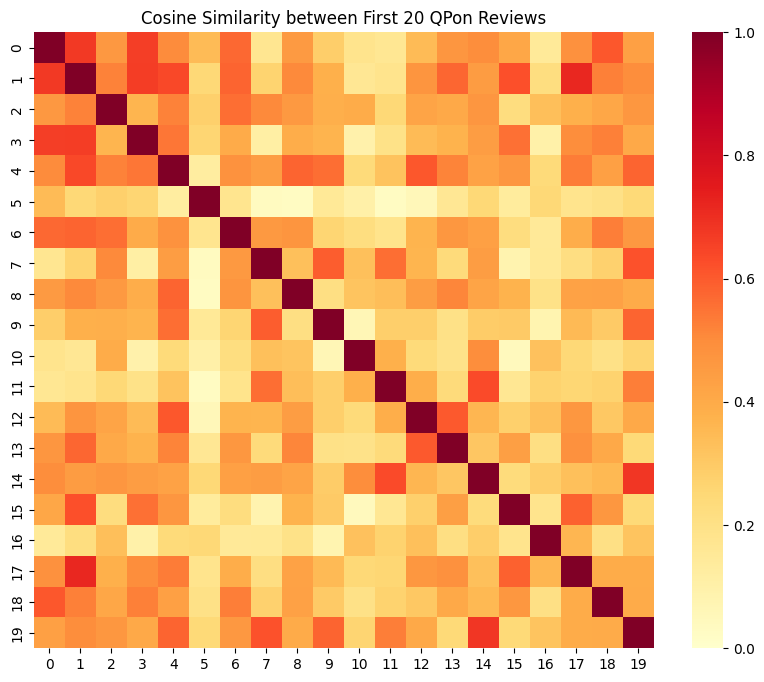

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings[:20])

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Cosine Similarity between First 20 QPon Reviews')
plt.show()

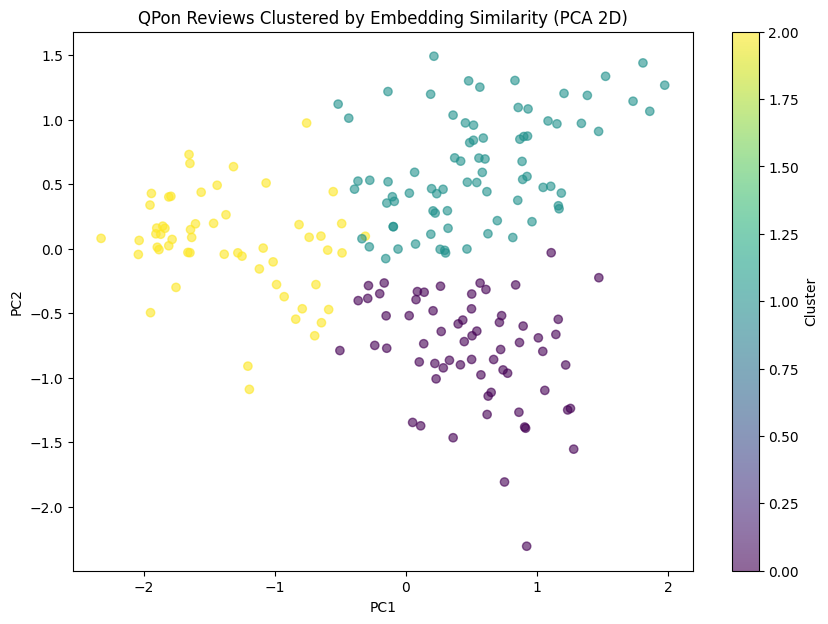


Cluster 0: 65 reviews, avg rating 1.71
  Masih aja lebih mahal blm saat menukarkan masih ada tambahan biaya lagi, pengalaman yang buruk, promonya harus ada minim
  karena pas flash sale yang di liat hanya brand aja alhasil gak bisa kepake dan jeleknya GAK ADA OPTION REFUND . saya di 

Cluster 1: 79 reviews, avg rating 1.72
  tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayan
  aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login 

Cluster 2: 56 reviews, avg rating 4.57
  aplikasi tidak bagus.. harga lebih mahal daripada beli di outlet.. contohnya hisana, pak d.. trus proses refund ribet ti
  Aplikasi Gaje, cuma pas pembelian awal doang yang bisa. Habis itu selalu Lagi banyak Peminat. Gak pernah bisa beli.


In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('QPon Reviews Clustered by Embedding Similarity (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# what's in each cluster?
df_sample = df.head(200).copy()
df_sample['cluster'] = clusters
for c in range(3):
    sub = df_sample[df_sample['cluster'] == c]
    avg_score = sub['score'].mean()
    print(f'\nCluster {c}: {len(sub)} reviews, avg rating {avg_score:.2f}')
    for t in sub['content'].head(2):
        print(f'  {str(t)[:120]}')

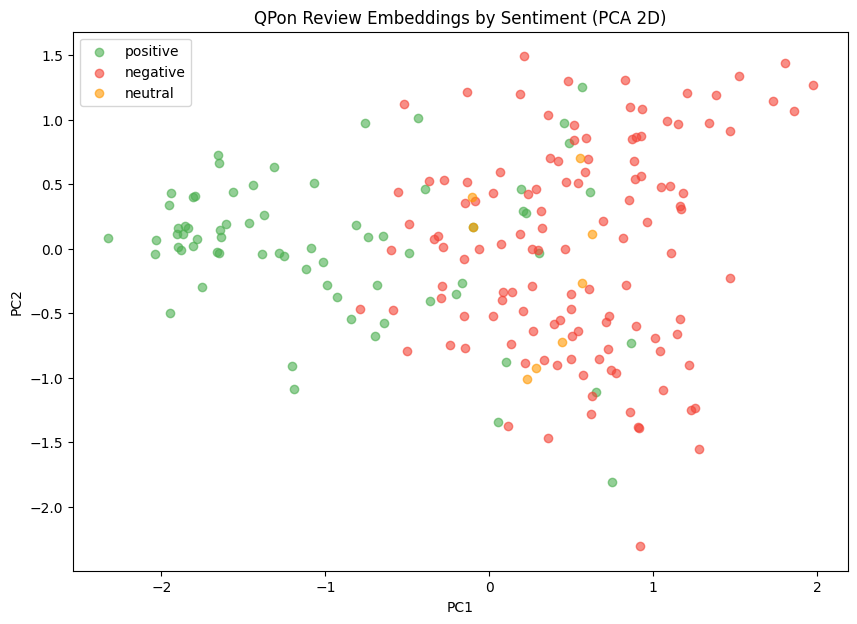

In [16]:
# color by sentiment instead of cluster
df_sample['sentiment'] = df_sample['score'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))
colors = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FF9800'}

plt.figure(figsize=(10, 7))
for sent, color in colors.items():
    mask = df_sample['sentiment'] == sent
    plt.scatter(coords[mask, 0], coords[mask, 1], c=color, label=sent, alpha=0.6)
plt.legend()
plt.title('QPon Review Embeddings by Sentiment (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

---
## Summary

**Keyword Extraction:** Compared three methods on QPon reviews:
- TF-IDF picks up globally important terms (promo, cashback, aplikasi)
- RAKE finds multi-word keyphrases from individual reviews
- TextRank extracts key sentences from longer reviews

**N-grams:** Bigrams and trigrams reveal common multi-word expressions in user feedback.

**Regex Variations:** Pattern matching found how many reviews mention error, promo, cashback, etc. and their correlation with ratings.

**Text Embeddings:** Sentence-BERT encodes reviews into dense vectors that capture meaning. Clustering and PCA visualization show that positive and negative reviews naturally separate in embedding space.